In [1]:
import re
import osmium
import subprocess
import os
os.environ['USE_PYGEOS'] = '0'
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from geopy.geocoders import Nominatim

In [2]:
os.getcwd()
os.chdir(os.path.join(os.getcwd(), 'backend'))

In [ ]:
LEVEL_HEIGHT = 3.4

# https://wiki.openstreetmap.org/wiki/Simple_3D_buildings#Other_roof_tags


def _feet_to_meters(s):
    r = re.compile(r"([0-9]*\.?[0-9]+)'([0-9]*\.?[0-9]+)?\"?")
    m = r.findall(s)[0]
    if len(m[0]) > 0 and len(m[1]) > 0:
        m = float(m[0]) + float(m[1]) / 12.0
    elif len(m[0]) > 0:
        m = float(m[0])
    return m * 0.3048


def _get_height(tags):
    if 'height' in tags:
        # already accounts for roof
        if '\'' in tags['height'] or '\"' in tags['height']:
            return _feet_to_meters(tags['height'])
        r = re.compile(r"[-+]?\d*\.\d+|\d+")
        return float(r.findall(tags['height'])[0])
    if 'levels' in tags:
        roof_height = 0
        if 'roof_height' in tags:
            if '\'' in tags['roof_height'] or '\"' in tags['roof_height']:
                roof_height = _feet_to_meters(tags['roof_height'])
            else:
                r = re.compile(r"[-+]?\d*\.\d+|\d+")
                roof_height = float(r.findall(tags['roof_height'])[0])

        # does not account for roof height
        height = float(tags['levels']) * LEVEL_HEIGHT
        if 'roof_levels' in tags and roof_height == 0:
            height += float(tags['roof_levels']) * LEVEL_HEIGHT
        return height
    return 7.0


def _get_min_height(tags):
    if 'min_height' in tags:
        # already accounts for roof
        if '\'' in tags['min_height'] or '\"' in tags['min_height']:
            return _feet_to_meters(tags['min_height'])
        r = re.compile(r"[-+]?\d*\.\d+|\d+")
        return float(r.findall(tags['min_height'])[0])
    if 'min_level' in tags:
        height = float(tags['min_level']) * LEVEL_HEIGHT
        return height
    return 0.0


class BuildingHandler(osmium.SimpleHandler):

    def __init__(self):
        osmium.SimpleHandler.__init__(self)
        self.geometry = []       # WKB bytes
        self.height = []
        self.min_height = []
        self.osm_id = []         # numeric id
        self.osm_type = []       # 'W' or 'R'
        self.wkbfab = osmium.geom.WKBFactory()

    def get_gdf(self):
        geom = gpd.GeoSeries.from_wkb(self.geometry, crs='EPSG:4326')
        gdf = gpd.GeoDataFrame({
            'osm_id': self.osm_id,
            'osm_type': self.osm_type,
            'min_height': pd.Series(self.min_height, dtype='float'),
            'height': pd.Series(self.height, dtype='float'),
            'geometry': geom
        }, index=geom.index)
        return gdf

    def area(self, a):
        id = int(a.orig_id())
        osm_type = 'W' if a.from_way() else 'R'

        tags = a.tags
        # Qualifiers
        if not ('building' in tags or 'building:part' in tags or tags.get('type', None) == 'building'):
            return
        # Disqualifiers
        if (tags.get('location', None) == 'underground' or 'bridge' in tags):
            return
        try:
            poly = self.wkbfab.create_multipolygon(a)
            height = _get_height(tags)
            min_height = _get_min_height(tags)

            self.geometry.append(poly)
            self.height.append(height)
            self.min_height.append(min_height)
            self.osm_id.append(id)
            self.osm_type.append(osm_type)
            
        except Exception as e:
            print(e)
            print(a)

def save_buildings_geojson(handler: BuildingHandler, out_path: str) -> gpd.GeoDataFrame:
    """
    Build a GeoDataFrame (with osm_id, osm_type, height, min_height, geometry)
    and save it as GeoJSON. Returns the GeoDataFrame.
    """
    gdf = handler.get_gdf()
    gdf.to_file(out_path, driver="GeoJSON")
    return

In [13]:
city_full = 'Chicago, Illinois, USA'
city = 'chi'
filename = 'data/%s.osm.pbf' % (city)
input_filename = 'data/north-america-latest.osm.pbf'

geolocator = Nominatim(user_agent='uic')
location = geolocator.geocode(city_full).raw
 
input_filename = 'data/north-america-latest.osm.pbf'

south, north, west, east = map(float, location['boundingbox'])
bbox = f"{west},{south},{east},{north}"

In [ ]:
# apt get install osmium-tool

subprocess.run([
    "osmium", "extract",
    "-b", bbox,
    "-o", filename,
    "--overwrite",
    input_filename
])



CompletedProcess(args=['osmium', 'extract', '-b', '-87.9400876,41.644531,-87.5240812,42.0230396', '-o', 'data/chi.osm.pbf', '--overwrite', 'data/north-america-latest.osm.pbf'], returncode=0)

In [27]:
h = BuildingHandler()
h.apply_file(filename, locations=True)

invalid area (area_id=324778144)
a324778144: num_rings=(0, 0), tags={addr:city=Chicago,addr:housenumber=2150,addr:po...}


In [ ]:
# gdf = h.get_gdf()
gdf.to_feather('data/%s_buildings.feather' % city, compression='lz4')


In [38]:
gdf = gpd.read_feather('data/chi_buildings.feather')

In [58]:
xmin, ymin, xmax, ymax = -87.655, 41.865, -87.605, 41.895
gdf_cut = gdf.cx[xmin:xmax, ymin:ymax]

In [59]:
gdf_cut.to_file('./data/chi_downtown_buildings.geojson', driver="GeoJSON")

In [1]:
import osmnx as ox
from pyrosm import OSM
# path to your local PBF
pbf_path = "./data/chi.osm.pbf"

osm = OSM(pbf_path)

nodes, edges = osm.get_network(
    network_type="driving",
    nodes=True,
    extra_attributes=["name", "highway", "maxspeed"]
)

# G = osm.to_graph(nodes, edges, graph_type="networkx")  # already EPSG:4326

# G = ox.simplify_graph(G)
# G = ox.project_graph(G)

c:\Users\qshah\Documents\Fall 2026\scout\backend\envs\lib\site-packages\osmnx\convert.py:6: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [16]:
edges.columns

Index(['access', 'area', 'bicycle', 'bicycle_road', 'bridge', 'busway',
       'cycleway', 'foot', 'footway', 'highway', 'junction', 'lanes', 'lit',
       'maxspeed', 'motorcar', 'motorroad', 'motor_vehicle', 'name', 'oneway',
       'psv', 'ref', 'service', 'segregated', 'sidewalk', 'smoothness',
       'surface', 'tracktype', 'tunnel', 'turn', 'width', 'id', 'timestamp',
       'version', 'tags', 'osm_type', 'geometry', 'u', 'v', 'length'],
      dtype='object')

In [29]:
edges = edges[['id', 'osm_type', 'geometry', 'width', 'length']]

In [30]:
edges = edges.set_crs(4326)             # ensure WGS84 (lon/lat)

In [ ]:
edges.to_feather("./data/chi_roads.feather")

In [33]:
xmin, ymin, xmax, ymax = -87.655, 41.865, -87.605, 41.895
edges = edges.cx[xmin:xmax, ymin:ymax]

In [ ]:
edges.to_file("./data/chi_downtown_edges.geojson", driver="GeoJSON")

In [ ]:
# edge speeds
# edge travel time

In [ ]:
from pyrosm import OSM
import osmnx as ox
import networkx as nx

pbf_path = "./data/chi.osm.pbf"

# Init reader
osm = OSM(pbf_path)

In [ ]:
# Get driving network with nodes=True
nodes_gdf, edges_gdf = osm.get_network(
    network_type="driving",
    nodes=True,  
    extra_attributes=["maxspeed", "lanes", "name", "oneway"]
)

In [ ]:
# Build MultiDiGraph
G = nx.MultiDiGraph()

# ---- add nodes ----
for _, row in nodes_gdf.iterrows():
    nid = int(row["id"])
    # OSMnx convention: x = lon, y = lat
    G.add_node(
        nid,
        x=float(row["lon"]),
        y=float(row["lat"]),
        # keep anything else if you care
        # timestamp=row["timestamp"],
        # visible=row["visible"],
    )

# ---- add edges ----
for _, row in edges_gdf.iterrows():
    u = int(row["u"])
    v = int(row["v"])

    # copy all edge attributes except u,v
    data = row.to_dict()
    data.pop("u", None)
    data.pop("v", None)

    # pyrosm typically already gives 'length' (in meters) and 'geometry'
    G.add_edge(u, v, **data)

In [12]:
print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

Nodes: 637237 Edges: 741271


In [14]:
G.graph["crs"] = "EPSG:4326"

In [ ]:
# ---- add speeds & travel times via OSMnx ----
G = ox.add_edge_speeds(G)        # adds edge attribute 'speed_kph'
G = ox.add_edge_travel_times(G)  # adds edge attribute 'travel_time' (seconds)

# ---- inspect as GeoDataFrame ----
edges = ox.utils_graph.graph_to_gdfs(G, nodes=False, edges=True)

In [27]:
edges = edges[['length', 'speed_kph', 'travel_time', 'geometry', 'width', 'name']]

In [ ]:
# ox.save_graphml(G, filepath="./data/graph_chicago.graphml")
# G_loaded = ox.load_graphml("./data/graph_chicago.graphml")

In [28]:
from shapely.geometry import LineString

# edges: GeoDataFrame with MultiIndex (u, v, key)
# columns: ['length', 'speed_kph', 'travel_time', 'geometry', 'width', 'name']

G = nx.MultiDiGraph()
G.graph["crs"] = "EPSG:4326"   # adjust to your CRS

# keep a dict for node coords so we don’t duplicate
node_coords = {}

for (u, v, k), data in edges.iterrows():
    geom = data["geometry"]
    if isinstance(geom, LineString):
        start_x, start_y = geom.coords[0]
        end_x, end_y = geom.coords[-1]

        node_coords[u] = (start_x, start_y)
        node_coords[v] = (end_x, end_y)

    # Add edge and attributes
    attr = data.drop(labels=["geometry"]).to_dict()
    attr["geometry"] = geom
    G.add_edge(u, v, key=k, **attr)

# Add nodes with x/y attributes
for nid, (x, y) in node_coords.items():
    G.add_node(nid, x=x, y=y)

print(f"Reconstructed MultiDiGraph: {len(G.nodes)} nodes, {len(G.edges)} edges")

Reconstructed MultiDiGraph: 637237 nodes, 741271 edges


In [29]:
# Define bounding box
minx, miny, maxx, maxy = (-87.65, 41.87, -87.62, 41.89)  # (lon_min, lat_min, lon_max, lat_max)

# Crop graph to bbox
G_crop = ox.truncate.truncate_graph_bbox(G, 
                                         north=maxy, south=miny, 
                                         east=maxx, west=minx)

print(len(G_crop.nodes), "nodes,", len(G_crop.edges), "edges")

C:\Users\qshah\AppData\Local\Temp\ipykernel_5232\4199596319.py:5: FutureWarning: The `north`, `south`, `east`, and `west` parameters are deprecated and will be removed in the v2.0.0 release. Use the `bbox` parameter instead. Note that the expected order of coordinates in `bbox` will change in the v2.0.0 release to `(left, bottom, right, top)`. See the OSMnx v2 migration guide: https://github.com/gboeing/osmnx/issues/1123
  G_crop = ox.truncate.truncate_graph_bbox(G,


8047 nodes, 8832 edges


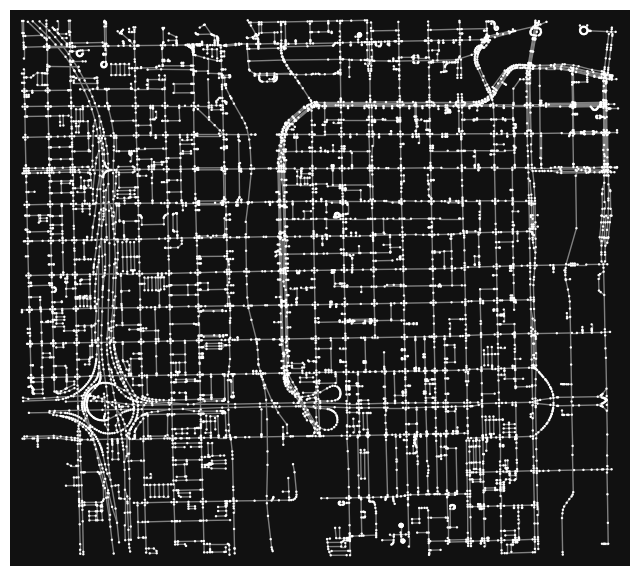

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [30]:
ox.plot_graph(G_crop, node_size=3, edge_color="gray")


In [ ]:
edges.to_feather("./data/chicago/roads.feather")